In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top/...`
* IR: 16 x 16 px
* Overlap = 50%
* SA = 16 x 16 px
* stepsize = 1
* dt = 0.008 s
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

## f = 1.4 Hz, A = 0.3 V

In [19]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/'
# Results from PIV processing
piv_a03_r1 = pd.read_csv(base_path + 'f14a03_zoom_res_r1.csv')
piv_a03_r2 = pd.read_csv(base_path + 'f14a03_zoom_res_r2.csv')
piv_a03_r3 = pd.read_csv(base_path + 'f14a03_zoom_res_r3.csv')

piv_a02_r1 = pd.read_csv(base_path + 'f14a02_zoom_res_r1.csv')
piv_a02_r2 = pd.read_csv(base_path + 'f14a02_zoom_res_r2.csv')
piv_a02_r3 = pd.read_csv(base_path + 'f14a02_zoom_res_r3.csv')

piv_a01_r1 = pd.read_csv(base_path + 'f14a01_zoom_res_r1.csv')
piv_a01_r2 = pd.read_csv(base_path + 'f14a01_zoom_res_r2.csv')
piv_a01_r3 = pd.read_csv(base_path + 'f14a01_zoom_res_r3.csv')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/'
# Results from probe analysis
prb_a03_p = pd.read_csv(base_path + '20cm_f14_a03_p005_results.csv')
prb_a02_p = pd.read_csv(base_path + '20cm_f14_a02_p005_results.csv')
prb_a01_p = pd.read_csv(base_path + '20cm_f14_a01_p005_results.csv')

prb_a03 = pd.read_csv(base_path + '20cm_f14_a03_results.csv')
prb_a02 = pd.read_csv(base_path + '20cm_f14_a02_results.csv')
prb_a01 = pd.read_csv(base_path + '20cm_f14_a01_results.csv')

# Post-processed probe data
eta_03_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a03_p005_r1_processed.csv')
eta_02_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a02_p005_r1_processed.csv')
eta_01_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a01_p005_r1_processed.csv')

eta_03 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a03_r1_processed.csv')
eta_02 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a02_r1_processed.csv')
eta_01 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a01_r1_processed.csv')

## The theoretical values
#### Damping coefficient
$\alpha_{theory} = \alpha_{Weber}/(1 + Q)$ 

$Q = \frac{(3 - D/H)gDh^4k^2}{288\nu^2}$ 

$ \alpha_{Weber} = kh^2\omega(D-H)/(24H\nu)$ 

#### Robin parameter
$R_{theory} = (2H\alpha_{theory})/k$

#### Vertical velocity at z = -H
$\operatorname{Re}\{\bar{w}(z=-H)\} =  g\eta(D-H)\frac{[2\omega\alpha k - (12\nu (k^2 + \alpha^2)/h^2)]}{(12\nu/h)^2 + \omega^2}$

In [25]:
start = piv_a03_r1['time_b'].iloc[0]
end = piv_a03_r1['time_b'].iloc[-1]

# Pick out the same time as the PIV data for comparison. 
eta_all_03_p = eta_03_p[(eta_03_p['time'] >= start) & (eta_03_p['time'] <= end)]
eta03_p = eta_all_03_p['P_0'].values * -1

eta_all_02_p = eta_02_p[(eta_02_p['time'] >= start) & (eta_02_p['time'] <= end)]
eta02_p = eta_all_02_p['P_0'].values * -1

eta_all_01_p = eta_01_p[(eta_01_p['time'] >= start) & (eta_01_p['time'] <= end)]
eta01_p = eta_all_01_p['P_0'].values * -1

In [26]:
# Pick out the same time as the PIV data for comparison. 
eta_all_03 = eta_03[(eta_03['time'] >= start) & (eta_03['time'] <= end)]
eta03 = eta_all_03['P_0'].values * -1

eta_all_02 = eta_02[(eta_02['time'] >= start) & (eta_02['time'] <= end)]
eta02 = eta_all_02['P_0'].values * -1

eta_all_01 = eta_01[(eta_01['time'] >= start) & (eta_01['time'] <= end)]
eta01 = eta_all_01['P_0'].values * -1

In [ ]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = estimate_wavenumber(f, D)

a_theory, a_weber = spatial_damping_coefficient(k, D, H, h)

# Robin parameter
R_theory = robin_parameter(H, a_theory, k)
R_weber = robin_parameter(H, a_weber, k)

In [42]:
# Amplitudes measured at first probe position
# Should be unaffected by the presence of plates
amp_03 = list(prb_a03['Amp_obs_P0'].values) + list(prb_a03_p['Amp_obs_P0'].values)
amp_02 = list(prb_a02['Amp_obs_P0'].values) + list(prb_a02_p['Amp_obs_P0'].values)
amp_01 = list(prb_a01['Amp_obs_P0'].values) + list(prb_a01_p['Amp_obs_P0'].values)

In [43]:
A03 = np.round(np.mean(amp_03), 3)
A02 = np.round(np.mean(amp_02), 3)
A01 = np.round(np.mean(amp_01), 3)

In [78]:
x = 8.06
t = time_piv

# Vertical velocity at z=-H
w_bar_theory_a03 = vertical_velocity(A03, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a02 = vertical_velocity(A02, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a01 = vertical_velocity(A01, D, H, f, a_theory, k, h, x, t)

In [79]:
ax.plot(t, piv_a03_r1['w_bar'], color='C0', label='PIV A=0.3 V')
ax.plot(t, piv_a02_r1['w_bar'], color='C1', label='PIV A=0.2 V')
ax.plot(t, piv_a01_r1['w_bar'], color='C2', label='PIV A=0.1 V')

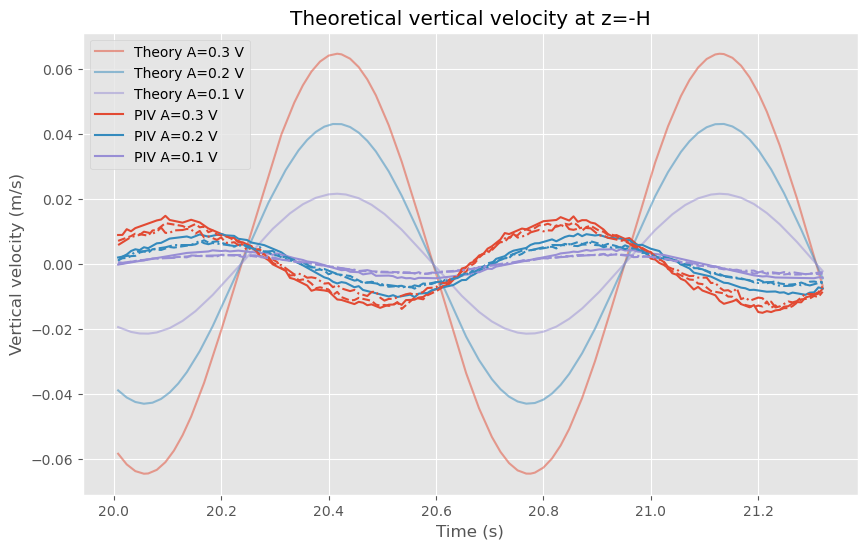

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, w_bar_theory_a03, color='C0', label='Theory A=0.3 V', alpha=0.5)
ax.plot(t, w_bar_theory_a02, color='C1', label='Theory A=0.2 V', alpha=0.5)
ax.plot(t, w_bar_theory_a01, color='C2', label='Theory A=0.1 V', alpha=0.5)

ax.plot(t, piv_a03_r1['w_bar'], color='C0', label='PIV A=0.3 V')
ax.plot(t, piv_a02_r1['w_bar'], color='C1', label='PIV A=0.2 V')
ax.plot(t, piv_a01_r1['w_bar'], color='C2', label='PIV A=0.1 V')

ax.plot(t, piv_a03_r2['w_bar'], color='C0', linestyle='--')
ax.plot(t, piv_a02_r2['w_bar'], color='C1', linestyle='--')
ax.plot(t, piv_a01_r2['w_bar'], color='C2', linestyle='--')

ax.plot(t, piv_a03_r3['w_bar'], color='C0', linestyle='-.')
ax.plot(t, piv_a02_r3['w_bar'], color='C1', linestyle='-.')
ax.plot(t, piv_a01_r3['w_bar'], color='C2', linestyle='-.')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Theoretical vertical velocity at z=-H')
ax.legend()

## Observed values

In [9]:
R_a03 = []

for run in ["R1", "R2", "R3"]:
    alpha = prb_a03[prb_a03['Run'] == run]['Alpha_obs'].values[0]
    R_a03.append(robin_parameter(0.15, k, alpha))

w_a03_r1 = piv_a03_r1['w_bar'].values
dw_a03_r1 = piv_a03_r1['dw_bar'].values

w_a03_r2 = piv_a03_r2['w_bar'].values
dw_a03_r2 = piv_a03_r2['dw_bar'].values

w_a03_r3 = piv_a03_r3['w_bar'].values
dw_a03_r3 = piv_a03_r3['dw_bar'].values

In [10]:
R_a02 = []

for run in ["R1", "R2", "R3"]:
    alpha = prb_a02[prb_a02['Run'] == run]['Alpha_obs'].values[0]
    R_a02.append(robin_parameter(0.15, k, alpha))

w_a02_r1 = piv_a02_r1['w_bar'].values
dw_a02_r1 = piv_a02_r1['dw_bar'].values

w_a02_r2 = piv_a02_r2['w_bar'].values
dw_a02_r2 = piv_a02_r2['dw_bar'].values

w_a02_r3 = piv_a02_r3['w_bar'].values
dw_a02_r3 = piv_a02_r3['dw_bar'].values

In [11]:
R_a01 = []

for run in ["R1", "R2", "R3"]:
    alpha = prb_a01[prb_a01['Run'] == run]['Alpha_obs'].values[0]
    R_a01.append(robin_parameter(0.15, k, alpha))

w_a01_r1 = piv_a01_r1['w_bar'].values
dw_a01_r1 = piv_a01_r1['dw_bar'].values

w_a01_r2 = piv_a01_r2['w_bar'].values
dw_a01_r2 = piv_a01_r2['dw_bar'].values

w_a01_r3 = piv_a01_r3['w_bar'].values
dw_a01_r3 = piv_a01_r3['dw_bar'].values

In [12]:
time_piv = np.linspace(start, end, len(w_a03_r1))
time_prb = np.linspace(start, end, len(eta03))

Text(0.5, 1.0, 'Vertical velocity at z=-H')

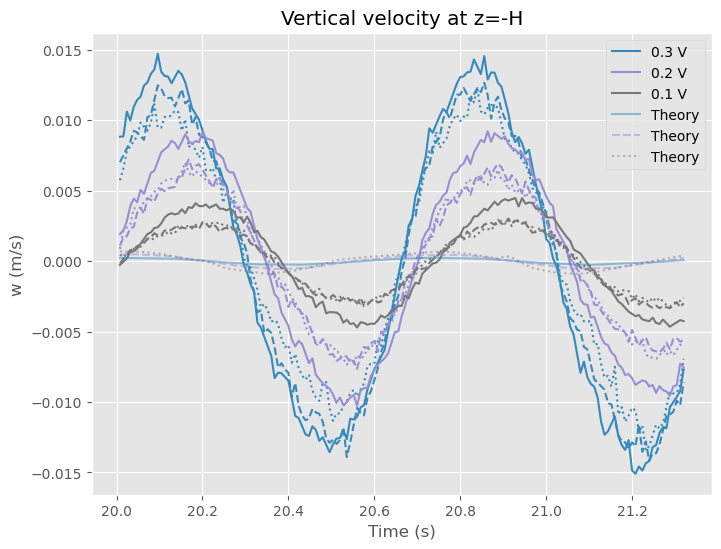

In [52]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(time_piv, w_a03_r1, color='C1', linestyle='-', label='0.3 V')
ax.plot(time_piv, w_a03_r2, color='C1', linestyle='--')
ax.plot(time_piv, w_a03_r3, color='C1', linestyle=':')

ax.plot(time_piv, w_a02_r1, color='C2', linestyle='-', label='0.2 V')
ax.plot(time_piv, w_a02_r2, color='C2', linestyle='--')
ax.plot(time_piv, w_a02_r3, color='C2', linestyle=':')

ax.plot(time_piv, w_a01_r1, color='C3', linestyle='-', label='0.1 V')
ax.plot(time_piv, w_a01_r2, color='C3', linestyle='--')
ax.plot(time_piv, w_a01_r3, color='C3', linestyle=':')

ax.plot(time_prb, w_theory_a01, color='C1', alpha=0.5, linestyle='-', label='Theory')
ax.plot(time_prb, w_theory_a02, color='C2', alpha=0.5, linestyle='--', label='Theory')
ax.plot(time_prb, w_theory_a03, color='C3', alpha=0.5, linestyle=':', label='Theory')

#ax.plot(time_prb, w_weber_a01, color='k', alpha=0.5, linestyle='-', label='Weber')
#ax.plot(time_prb, w_weber_a02, color='k', alpha=0.5, linestyle='--', label='Weber')
#ax.plot(time_prb, w_weber_a03, color='k', alpha=0.5, linestyle=':', label='Weber')

ax.legend()
ax.set_xlabel('Time (s)')
ax.set_ylabel('w (m/s)')
ax.set_title('Vertical velocity at z=-H')

In [16]:
a_obs_a03 = prb_a03['Alpha_obs'].values
a_obs_a02 = prb_a02['Alpha_obs'].values
a_obs_a01 = prb_a01['Alpha_obs'].values

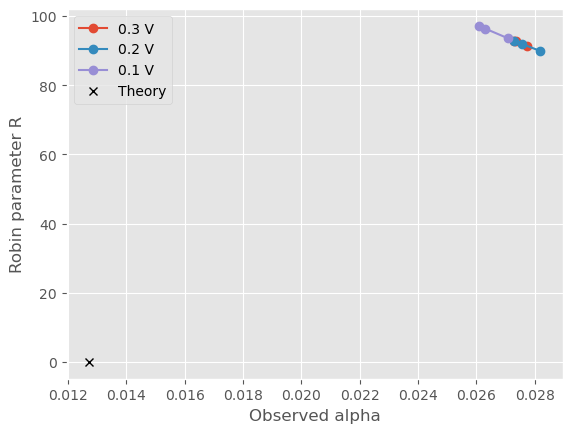

In [17]:
plt.plot(a_obs_a03, R_a03, 'o-', label='0.3 V')
plt.plot(a_obs_a02, R_a02, 'o-', label='0.2 V')
plt.plot(a_obs_a01, R_a01, 'o-', label='0.1 V')

plt.plot(a_theory, R_theory, 'kx', label='Theory')

plt.xlabel('Observed alpha')
plt.ylabel('Robin parameter R')
plt.legend()

In [30]:
np.max(w_a03_r1)

np.float64(0.021924245424367)

In [25]:
a03_r1_zoom = pd.read_csv('/Users/kjesta/Desktop/LABDATA/PIV/results/zoom/f14a01_zoom_res_r1.csv')

In [26]:
w_a03_zoom = a03_r1_zoom['w_bar'].values

In [31]:
np.max(w_a03_zoom) 

np.float64(0.0010180827910596)